# PCLab#2







In this project, we assume the role of newly hired analysts at a small hedge fund transitioning from passive to active investment strategies, with a stronger focus on returns rather than capital allocation size. Our primary objective is to estimate the systematic risk (beta) of eight selected stocks and use this information to better understand portfolio risk dynamics. As in the previous lab, we operate under the assumption of zero transaction costs, allowing us to focus purely on risk and return considerations.

# Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
import plotly.express as px
import plotly.figure_factory as ff
import statsmodels.api as sm
from xml.dom.expatbuilder import theDOMImplementation
from copy import copy
from scipy import stats
import requests, bs4
from datetime import datetime
import yfinance as yf
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from plotly.colors import sample_colorscale
from ipywidgets import interact, widgets
import matplotlib.ticker as mtick
from scipy.stats import normaltest


In [ ]:
df = pd.read_csv('./data/Data_PCLab1_Stock.csv')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


# **Optional Task**: Obtain data from the web

To gather data from the web we first scraped the list of S&P500 companies from Wikipedia, gathering all the ticker symbols. Then we gathered historical stock price data via the yfinance library, for a time period spanning from Jannuary 12th 2012 to August 8th 2020, consistently with the time frame of the provided dataset.

In [ ]:
url = "https://en.wikipedia.org/wiki/List_of_S%26P_500_companies"
resp = requests.get(url, headers={"User-Agent": "Mozilla/5.0"})
resp.raise_for_status()

soup = bs4.BeautifulSoup(resp.text, "lxml")

table = soup.select_one("table#constituents")
rows = table.select("tbody tr")[1:]

tickers = []
for r in rows:
    t = r.select_one("td").get_text(strip=True)
    tickers.append(t)

tickers = [t.replace(".", "-") for t in tickers]

start = datetime(2012, 1, 12)
end   = datetime(2020, 8, 11)

data = yf.download(tickers, start=start, end=end, group_by="ticker", auto_adjust=False)

[*********************100%***********************]  503 of 503 completed
ERROR:yfinance:
13 Failed downloads:
ERROR:yfinance:['ABNB', 'GEHC', 'DASH', 'SOLV', 'COIN', 'VLTO', 'GEV', 'CEG', 'EXE', 'APP', 'HOOD', 'PLTR', 'KVUE']: YFPricesMissingError('possibly delisted; no price data found  (1d 2012-01-12 00:00:00 -> 2020-08-11 00:00:00) (Yahoo error = "Data doesn\'t exist for startDate = 1326344400, endDate = 1597118400")')


In [ ]:
df_web = (data.stack(level=0).reset_index().set_index("Date"))

df_web.columns.name = None

df_web = df_web.reset_index()
df_web.head()

/tmp/ipython-input-1048013887.py:1: FutureWarning:

The previous implementation of stack is deprecated and will be removed in a future version of pandas. See the What's New notes for pandas 2.1.0 for details. Specify future_stack=True to adopt the new implementation and silence this warning.



,Date,Ticker,Open,High,Low,Close,Adj Close,Volume
0,2012-01-12,A,27.997139,28.311874,27.439199,28.268955,25.166063,3973396.0
1,2012-01-12,AAPL,15.081429,15.103571,14.955357,15.049643,12.650179,212587200.0
2,2012-01-12,ABT,26.700871,26.811224,26.446575,26.465769,20.267302,15528762.0
3,2012-01-12,ACGL,12.310000,12.403333,12.310000,12.403333,11.794311,1439700.0
4,2012-01-12,ACN,53.189999,54.060001,53.000000,53.939999,41.967861,5096400.0


# **Task 1**: Visualization and 1st step toward the CAPM

To **compare each stock daily return with market ones**, we computed daily returns for each stock by taking the percentage changes in the adjusted closing prices as:
$$
R_{i,t} = \frac{P_{i,t}}{P_{i,t-1}}-1 \space \text{ for each stock i,}
$$

$$
R_{m,t} = \frac{P_{m,t}}{P_{m,t-1}}-1
$$


Each stock's daily returns were then plotted against the market's (in this dataset **inteded as the S&P500** since it encompasses the 500 biggest companies in the US economy).



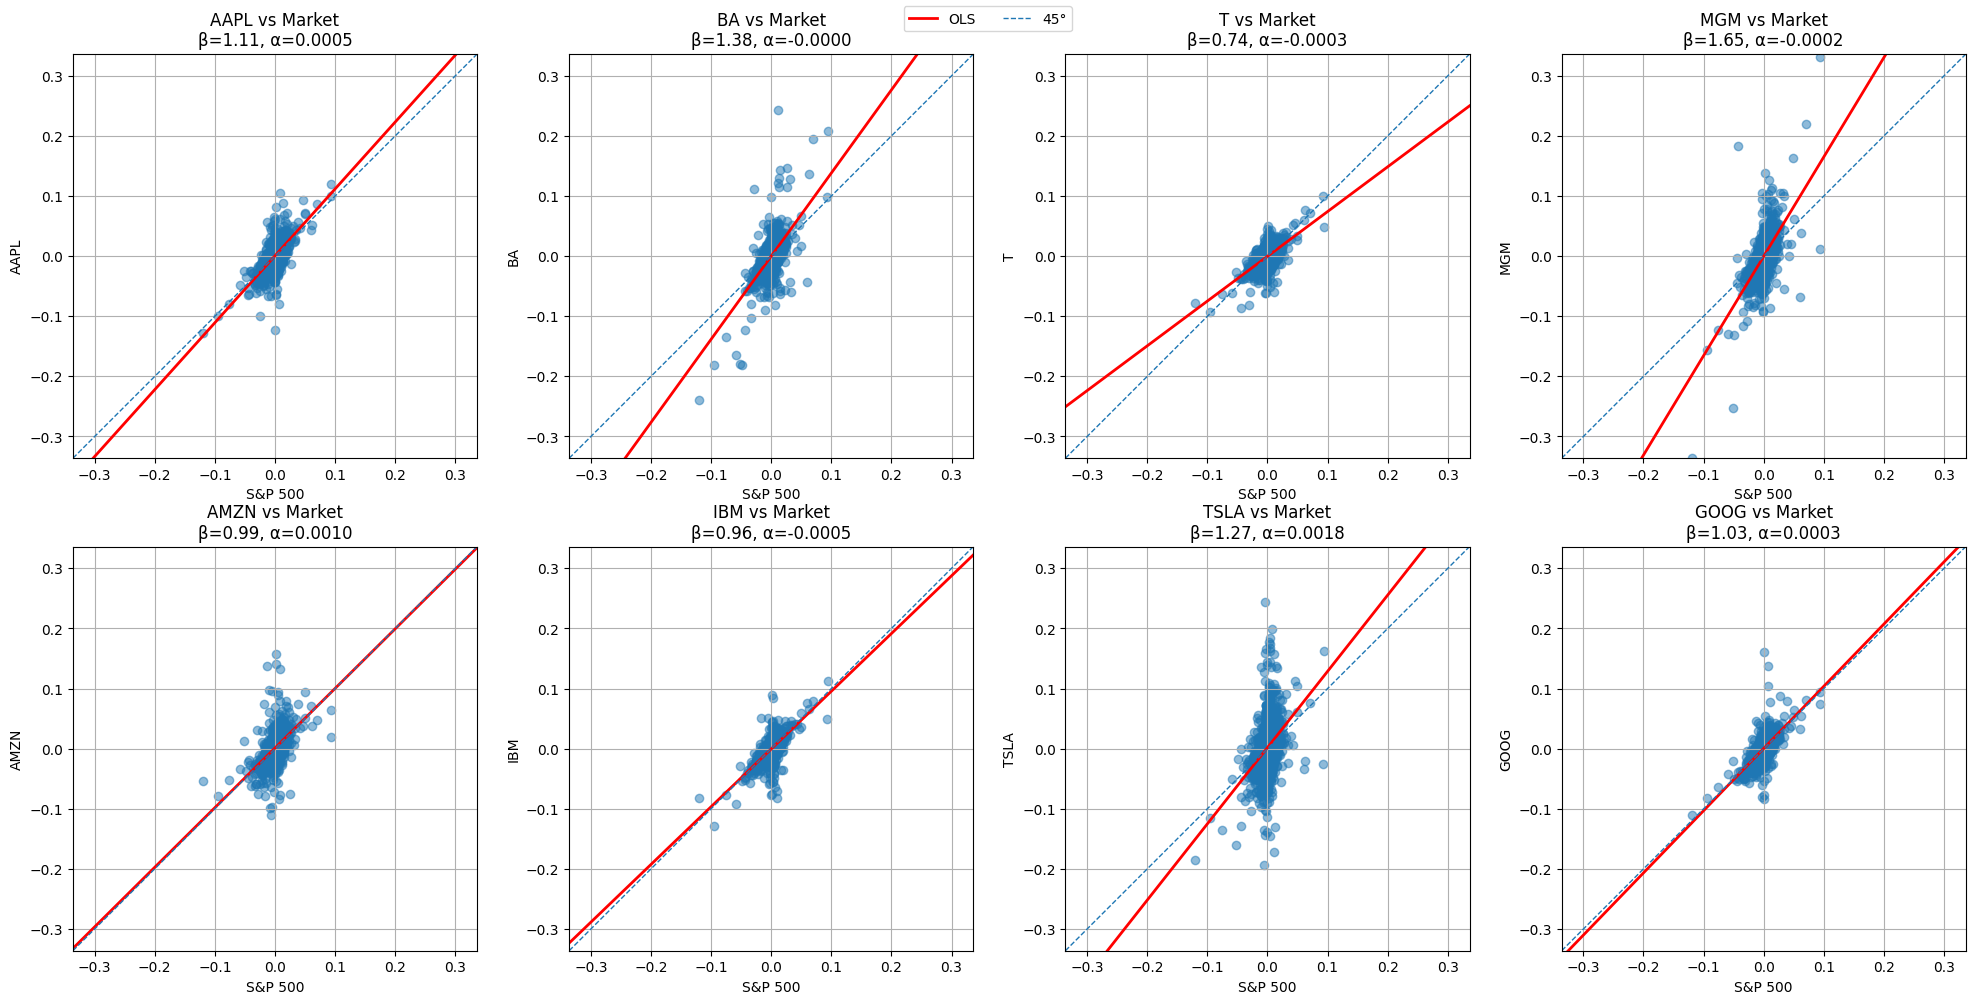

In [ ]:
returns = df.set_index("Date").pct_change().dropna()
market_col = "sp500"
stocks = [col for col in returns.columns if col != market_col]

beta = {}
alpha = {}

x_min, x_max = returns[market_col].min(), returns[market_col].max()
y_min, y_max = returns[stocks].min().min(), returns[stocks].max().max()
M = float(np.max(np.abs([x_min, x_max, y_min, y_max])))

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
x_ref = np.array([-M, M])

for ax, stock in zip(axes.flatten(), stocks):
    ax.scatter(returns[market_col].values, returns[stock].values, alpha=0.5)

    # trend line (OLS fit): y = a + b x
    b, a = np.polyfit(returns[market_col].values, returns[stock].values, 1)
    y_line = a + b * x_ref
    ax.plot(x_ref, y_line, color='red', linewidth=2, label='OLS')

    # 45° (y = x)
    ax.plot(x_ref, x_ref, linestyle='--', linewidth=1, label='45°')

    ax.set_title(f"{stock} vs Market\nβ={b:.2f}, α={a:.4f}")
    ax.grid(True)
    ax.set_xlabel("S&P 500")
    ax.set_ylabel(f"{stock}")

    ax.set_xlim(-M, M)
    ax.set_ylim(-M, M)
    ax.set_aspect('equal', adjustable='box')

    beta[stock] = b
    alpha[stock] = a

handles, labels = axes.flatten()[0].get_legend_handles_labels()
fig.legend(handles, labels, loc='upper center', ncol=2)

fig.tight_layout()
plt.show()


The **red line** plotted above was computed, in accordance with the CAPM framework, as follows: $$r_{i,t}= \alpha_{i,t} + \beta_{i,t} * r_{M,t}$$

This line shows the **direction and average size of co-movements** of, respectively, each stock and the market. More in detail, a slope near 1 (corresponding to the blue dotted line) suggests roughly one-for-one moves while, for example, above 1 amplifies market swings (to know more in detail how the slope was computed, refer to point 2).

The **tightness of the blue points around the red line** reflects the **strength of correlation**: tighter means stronger correlation while a diffuse cloud translates into a weaker relationship. Overall, looking at the **dots' position**, we see a positive correlation between the market and all the stocks in the dataset. More in detail, we see that:
1) IBM and Google's returns' distributions **follow closely the OLS line**.
2) Tesla and Amazon have **wider scatter** and outliers, indicating **lower correlation** with market movements.

To verify these assumptions more rigorously we **computed the correlation** among each singular stock and the market.

As one can see below, our initial thesis about **IBM** and Google was confirmed, closely followed by Apple which ranked third among those with the **strongest correlation**. This resonates with the fact that large and well-established companies are heavily integrated into the S&P500, contributing to and reflecting more broader market movements. At the same time, **Tesla** stands out with the **lowest correlation** (0.39),suggesting a more idiosyncratic behaviour, influenced by company-specific factors such as innovation cycles, investor sentiment, and regulatory news.

In [ ]:
market_col = "sp500"
stocks = [c for c in returns.columns if c != market_col]

correlations = {}

for stock in stocks:
    corr = returns[stock].corr(returns[market_col])
    correlations[stock] = corr
    print(f"Correlation between {stock} and market: {corr:.2f}")

max_corr_stock = max(correlations, key=correlations.get)
print(f"\nStock most correlated with the market: {max_corr_stock} (r={correlations[max_corr_stock]:.2f})")

Correlation between AAPL and market: 0.66
Correlation between BA and market: 0.64
Correlation between T and market: 0.62
Correlation between MGM and market: 0.63
Correlation between AMZN and market: 0.54
Correlation between IBM and market: 0.70
Correlation between TSLA and market: 0.39
Correlation between GOOG and market: 0.68

Stock most correlated with the market: IBM (r=0.70)


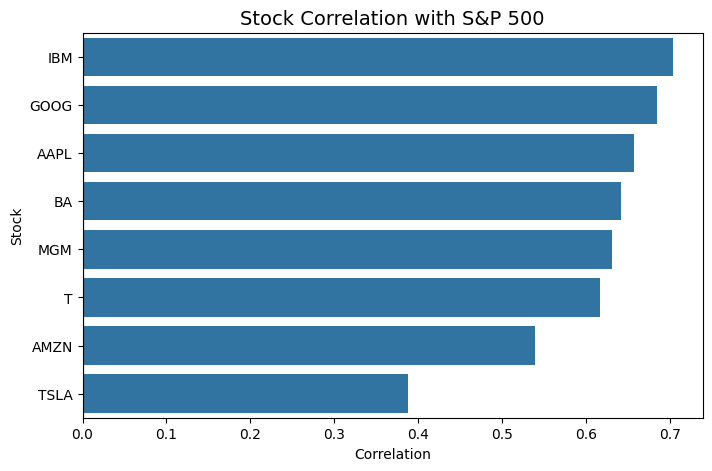

In [ ]:
sorted_corr = {k: v for k, v in sorted(correlations.items(), key=lambda item: item[1], reverse=True)}

plt.figure(figsize=(8,5))
sns.barplot(x=list(sorted_corr.values()), y=list(sorted_corr.keys()))
plt.axvline(0, color='black', linewidth=0.8)
plt.title("Stock Correlation with S&P 500", fontsize=14)
plt.xlabel("Correlation")
plt.ylabel("Stock")
plt.show()

# **Task 2**: Compute alpha and beta


### Applying the CAPM: OLS Regression

Here below we applied the CAPM model which, in its excess-return form, can be expressed as follows:

$$r_i-r_f = \alpha_i + \beta_i (r_m-r_f) + \epsilon_i$$

where:

* $r_i$: daily return of stock $i$;

* $r_m$: daily return of the market portfolio (S&P500 index);

* $\alpha_i$: **intercept** of the regression line; it corresponds to the average **return unexplained by the market** (abnormal return) when the market’s return is 0.

* $\beta_i$: **slope** of the regression line; it represents the stock's **sensitivity to the market**. More precisely, a 1% market move is associated with a corresponding average $\beta_i$% move in the stock.

* $\epsilon_i$: error term.

For simplicity, here we **assume that the risk-free rate is zero**.

To estimate sing and magnitude of the $\beta_i$ and $\alpha_i$ of each stock in the dataset we run an **OLS regression** of its returns on the market return. Besides these estimates, we also stored valuable information such as as their t-statistics, p-values, $R^2$ and the total number of observations.

The results are summarized in a dataframe, from which we:

* Report parameter estimates and test for **significance** at the 5% level;

* Identify the stocks with the highest and lowest values of $\alpha$ and $\beta$.

In [ ]:
results, rows = {}, []

for s in stocks:
    pair = returns[[s, market_col]].dropna()
    y = pair[s]
    X = sm.add_constant(pair[market_col])

    res = sm.OLS(y, X).fit()
    results[s] = res
    rows.append({
        "stock": s,
        "alpha":   res.params["const"],
        "beta":    res.params[market_col],
        "alpha_t": res.tvalues["const"],
        "beta_t":  res.tvalues[market_col],
        "alpha_pval": res.pvalues["const"],
        "beta_pval":  res.pvalues[market_col],
        "R2": res.rsquared,
        "n_obs": int(res.nobs)})

summary_df = pd.DataFrame(rows).set_index("stock").sort_index()
sig= pd.DataFrame({
    "alpha_sig_5pct": summary_df["alpha_pval"] < 0.05,
    "beta_sig_5pct":  summary_df["beta_pval"]  < 0.05}).astype(bool)
final= pd.merge(summary_df, sig, on= 'stock').reset_index()


final

,stock,alpha,beta,alpha_t,beta_t,alpha_pval,beta_pval,R2,n_obs,alpha_sig_5pct,beta_sig_5pct
0,AAPL,0.000528,1.112891,1.831244,40.499922,0.067202,3.521164e-267,0.432070,2158,False,True
1,AMZN,0.001023,0.991732,2.922175,29.756303,0.003512,2.611172e-163,0.291125,2158,True,True
2,BA,-0.000023,1.382867,-0.061338,38.862544,0.951096,7.299279e-251,0.411941,2158,False,True
3,GOOG,0.000334,1.034881,1.339176,43.606173,0.180655,2.345742e-298,0.468638,2158,False,True
4,IBM,-0.000535,0.960416,-2.440489,46.018972,0.014747,1.185758e-322,0.495525,2158,True,True
5,MGM,-0.000169,1.653568,-0.367897,37.811805,0.712986,1.874186e-240,0.398728,2158,False,True
6,T,-0.000286,0.744630,-1.332180,36.448649,0.182942,4.892378e-227,0.381261,2158,False,True
7,TSLA,0.001759,1.268611,2.580881,19.542490,0.009920,1.965135e-78,0.150482,2158,True,True


The regression estimates of **beta** are all **statistically significant**. More in detail, **MGM and BA** are the **most sensitive** stocks (betas above 1.3). This implies, for instance, that if the market increases by 1%, MGM increases on average by 1.65%. Furthermore, also Apple, Google, and Amazon move closely with the market while, on the contrary, T is the **least sensitive** (0.74), consistent with its defensive and stable nature as a telecom provider.

On the other hand, most **alphas** are **not significant**, meaning that stocks returns are largely explained by market movements. In fact, the classical version of the CAPM model traditionally assumes $\alpha$ equal to zero. However, Amazon and Tesla dispaly a **positive and significant alpha** (meaning excess return compared to its risk-adjust award), and IBM a small negative significant alpha, pointing to potential underperformance relative to its risk profile. This might be due to model misspecification or to some omitted factors relative to these specific companies. More in detail, a plausible reason might be that, within the years spanning from 2012 to 2020, Amazon and Tesla showed besides market trends a strong growth and momentum tilts **beyond current market trends**, while IBM was more a consolidated and low-growth firm.

Finally, consistent with the previously computed correlations, **Google and IBM have the strongest fit with the market** (R² ≈ 0.5), while Tesla’s low R² (0.15) highlights that much of its variation is driven by firm-specific factors rather than the market.


### Betas and Alphas plots

This code visualizes and summarizes with an interactive plot **stocks’ betas and alphas**, showing bar charts for each and printing the stocks with the highest and lowest values.


In [ ]:
beta_alpha_df = summary_df.loc[stocks, ["beta", "alpha"]].copy().dropna()
beta_alpha_df = beta_alpha_df.sort_values("beta")

names = beta_alpha_df.index.astype(str).to_list()
beta_vals  = beta_alpha_df["beta"].to_numpy()
alpha_vals = beta_alpha_df["alpha"].to_numpy()

norm = (beta_vals - beta_vals.min()) / (beta_vals.max() - beta_vals.min())
colors = sample_colorscale("RdBu", norm)

fig = make_subplots(rows=1, cols=2, shared_yaxes=True,horizontal_spacing=0.05,
    subplot_titles=("Estimated Beta by Stock", "Estimated Alpha by Stock"))

fig.add_trace(
    go.Bar(
        x=beta_vals, y=names, orientation="h",
        marker=dict(color=colors),
        text=[f"{v:.2f}" for v in beta_vals],
        textposition="outside",
        hovertemplate="Stock: %{y}<br>Beta: %{x:.4f}<extra></extra>",
        showlegend=False),row=1, col=1)
fig.add_vline(x=1.0, line_dash="dash", line_color="grey", line_width=1, row=1, col=1)

fig.add_trace(
    go.Bar(
        x=alpha_vals, y=names, orientation="h",
        marker=dict(color=colors),
        text=[f"{v:.5f}" for v in alpha_vals],
        textposition="outside",
        hovertemplate="Stock: %{y}<br>Alpha (daily): %{x:.6f}<extra></extra>",
        showlegend=False), row=1, col=2)
fig.add_vline(x=0.0, line_dash="dash", line_color="grey", line_width=1, row=1, col=2)


n = len(names)
height = min(900, max(450, 26 * n + 120))
fig.update_layout(
    height=height, width=1200,
    margin=dict(l=10, r=20, t=50, b=40),
    bargap=0.15)
fig.update_yaxes(title_text="", automargin=True)

fig.show()

hi_beta, lo_beta  = summary_df["beta"].idxmax(), summary_df["beta"].idxmin()
hi_alpha, lo_alpha = summary_df["alpha"].idxmax(), summary_df["alpha"].idxmin()
print(f"\nHighest beta:  {hi_beta}  (β={summary_df.at[hi_beta,'beta']:.4f})")
print(f"Lowest beta:   {lo_beta}  (β={summary_df.at[lo_beta,'beta']:.4f})")
print(f"Highest alpha: {hi_alpha} (α={summary_df.at[hi_alpha,'alpha']:.6f} per day)")
print(f"Lowest alpha:  {lo_alpha} (α={summary_df.at[lo_alpha,'alpha']:.6f} per day)")



Highest beta:  MGM  (β=1.6536)
Lowest beta:   T  (β=0.7446)
Highest alpha: TSLA (α=0.001759 per day)
Lowest alpha:  IBM (α=-0.000535 per day)


### Error Terms

This code plots **histograms of regression residuals**, computed as follows:

$$\epsilon_i = r_i - \hat{r_i}$$

where $\hat{r_i}$ are the expected returns estimated as follows:

$$\hat{r_i} = \alpha_i + \beta_i r_m$$

For each stock residuals' we a fitted normal curve to compare their empirical distribution with the theoretical one and then stored some useful summary statistics (mean, standard deviation, skewness, kurtosis).


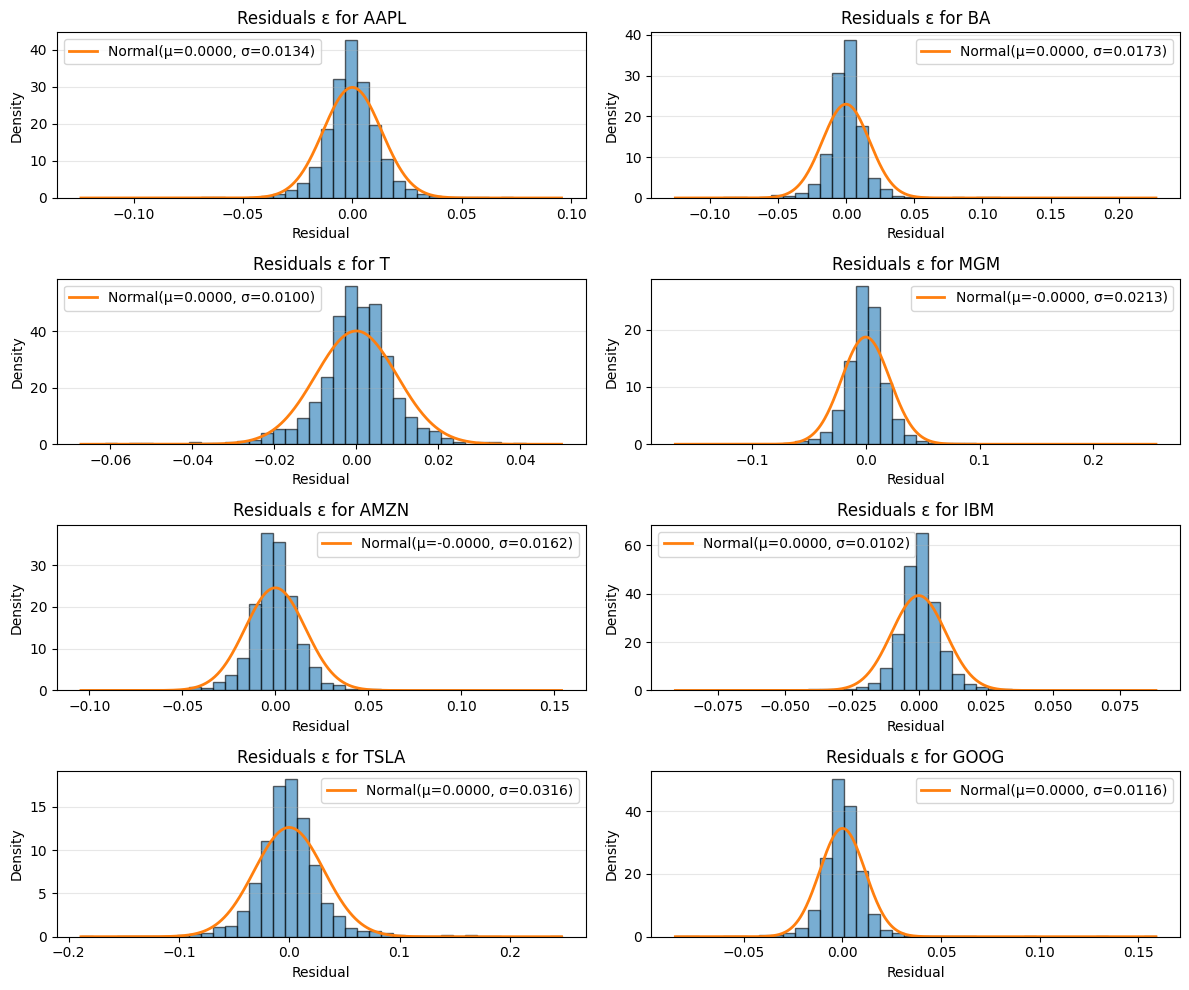


 Residual stats 
      mean     std    skew     kurt
AAPL   0.0  0.0134 -0.0681   9.0496
BA     0.0  0.0173  1.2928  26.7771
T      0.0  0.0100 -0.8131   5.7792
MGM   -0.0  0.0213  0.6526  19.8832
AMZN  -0.0  0.0162  1.2256  17.3880
IBM    0.0  0.0102 -0.8628  17.9319
TSLA   0.0  0.0316  0.6639   7.9381
GOOG   0.0  0.0116  1.8252  31.4961


In [ ]:
fig, axes = plt.subplots(4, 2, figsize=(12, 10))
axes = axes.flatten()

for ax, s in zip(axes, stocks):
    resid = results[s].resid.dropna()

    ax.hist(resid, bins=40, density=True, edgecolor="black", alpha=0.6)

    mu, sigma = resid.mean(), resid.std(ddof=1)
    x = np.linspace(resid.min(), resid.max(), 500)
    ax.plot(x, stats.norm.pdf(x, loc=mu, scale=sigma), linewidth=2,
            label=f"Normal(μ={mu:.4f}, σ={sigma:.4f})")

    ax.set_title(f"Residuals ε for {s}")
    ax.set_xlabel("Residual")
    ax.set_ylabel("Density")
    ax.grid(True, axis="y", alpha=0.3)
    ax.legend()

fig.tight_layout()
plt.show()

resid_stats = pd.DataFrame({
    s: {"mean": results[s].resid.mean(),
        "std":  results[s].resid.std(ddof=1),
        "skew": results[s].resid.skew(),
        "kurt": results[s].resid.kurt()}
    for s in stocks}).T
print("\n Residual stats ")
print(resid_stats.round(4))

These histograms show that, for all stocks within our dataset, residuals are approximately **centered around zero** ($\mu \approx 0$), indicating the model is unbiased. Standard deviations vary across stocks, with Tesla (0.0316) and MGM (0.0213) displaying higher residual volatility compared to IBM (0.0102) and AT&T (0.0100). This might be due to the fact that, while stable firms such as IBM and AT&T align more closely with the market, more volatile or idiosyncratic stocks like Tesla and MGM may naturally leave larger unexplained variation in a CAPM framework.

In [ ]:
def significancy(x):
    if x < 0.05:
        return 'Significant'
    else:
        return 'Not significant'
normality = {}

for s in stocks:
    normality[s] = normaltest(results[s].resid.dropna().iloc[1:])

normality_df = pd.DataFrame(normality, index=['Statistic', 'p-value']).T
normality_df['Significancy'] = normality_df['p-value'].apply(significancy)
normality_df

,Statistic,p-value,Significancy
AAPL,366.154955,3.093583e-80,Significant
BA,977.119619,6.624768e-213,Significant
T,457.531392,4.449596e-100,Significant
MGM,669.718353,3.736864e-146,Significant
AMZN,856.035176,1.301138e-186,Significant
IBM,721.333897,2.313846e-157,Significant
TSLA,501.552294,1.228296e-109,Significant
GOOG,1217.786246,3.639792e-265,Significant


Under these levels of significance, we can reject the null hypothesis of a Normal distribution for the residuals. This means that we can conclude that the **residuals are not normally distributed**, indicating that the model does not fully capture the dynamics of stock returns. In financial terms, such deviations suggest that additional risk factors, company-specific events, or market frictions are influencing returns beyond what is explained by the market alone.

### Portfolio of risky stocks

In [ ]:
top4_idx = summary_df["beta"].abs().nlargest(4).index
beta4 = summary_df.loc[top4_idx, "beta"]
alpha_daily = summary_df.loc[top4_idx, "alpha"]

print("\nTop-4 riskiest stocks by beta:")
print(beta4)


Top-4 riskiest stocks by beta:
stock
MGM     1.653568
BA      1.382867
TSLA    1.268611
AAPL    1.112891
Name: beta, dtype: float64


In [ ]:
rf_daily = 0.0 #as we always assume risk free rate = 0
Rm = returns[market_col]
E_Rm_daily = returns[market_col].mean()

# Regression-based expected returns (α ≠ 0)
E_Ri_regression_daily = rf_daily + alpha_daily + beta4 * (E_Rm_daily - rf_daily)

to_annual = lambda x: x * 252
E_Ri_regression_annual = to_annual(E_Ri_regression_daily)

print("Regression expected returns (annualized):")
print(E_Ri_regression_annual.sort_values(ascending=False))

Regression expected returns (annualized):
stock
TSLA    0.601041
AAPL    0.271518
BA      0.166162
MGM     0.163024
dtype: float64


In [ ]:
w = np.array([0.25, 0.25, 0.25, 0.25])

E_Rp_regression_daily = float(np.dot(w, E_Ri_regression_daily))

print(f"Mean market return (annualized): {to_annual(E_Rm_daily):.6f}")
print(f"EW portfolio expected (α≠0, daily): {E_Rp_regression_daily:.6f}")
print(f"EW portfolio expected (α≠0, annualized): {to_annual(E_Rp_regression_daily):.4%}")

Mean market return (annualized): 0.124334
EW portfolio expected (α≠0, daily): 0.001192
EW portfolio expected (α≠0, annualized): 30.0436%


The equally-weighted portfolio of the top 4 risky stocks has an expected annual return of **~30.0%**.

But how much of this return can be attributed due to alpha and how much to beta? To answer this question we computed the expected returns according to the **traditional CAPM equation which assumes α=0**, and then compared the results.

In [ ]:
E_Ri_capm_daily = rf_daily + beta4 * (E_Rm_daily - rf_daily)
E_Ri_capm_annual = to_annual(E_Ri_capm_daily)
E_Rp_capm_daily = float(np.dot(w, E_Ri_capm_daily))

print(f"EW portfolio expected (α=0, daily): {E_Rp_capm_daily:.6f}")
print(f"EW portfolio expected (α=0, annualized): {to_annual(E_Rp_capm_daily):.4%}")

EW portfolio expected (α=0, daily): 0.000668
EW portfolio expected (α=0, annualized): 16.8408%


If we don't allow an alpha the annual result is equal to **~16.8%**, compared to the previous**~30.0%**.

This gap reflects the contribution of abnormal returns (α) beyond what can be explained by systematic market risk (β). In other words, while traditional CAPM attributes portfolio performance entirely to market exposure, the regression model suggests that **part of the portfolio’s return is driven by stock-specific factors** that consistently add value.

#### Plotting our results

In [ ]:
top4 = list(top4_idx)

plot_df = pd.DataFrame({
    "stock": top4,
    "beta":  summary_df.loc[top4, "beta"].values,
    "alpha": summary_df.loc[top4, "alpha"].values,
    "vol_ann": (returns[top4].std() * np.sqrt(252)).values})
plot_df["reg_ann"] = (rf_daily + plot_df["alpha"] + plot_df["beta"]*(E_Rm_daily - rf_daily)) * 252

w = np.repeat(1/len(top4), len(top4))
Rp = (returns[top4] @ w)
idx = Rp.index.intersection(Rm.index)

beta_p  = plot_df["beta"].mean()
alpha_p = plot_df["alpha"].mean()
mkt_mu_ann  = E_Rm_daily * 252
mkt_vol_ann = Rm.std() * np.sqrt(252)
rp_mu_reg_ann = (rf_daily + alpha_p + beta_p*(E_Rm_daily - rf_daily)) * 252
rp_vol_ann    = Rp.loc[idx].std() * np.sqrt(252)

fig = go.Figure()

fig.add_trace(go.Scatter(
    x=plot_df["vol_ann"], y=plot_df["reg_ann"], mode="markers+text",
    text=plot_df["stock"], textposition="top center",
    marker=dict(size=12, color="blue"),
    name="Stocks (α≠0)",
    hovertemplate="Stock: %{text}<br>σ: %{x:.1%}/yr<br>E[R]: %{y:.2%}/yr<extra></extra>"))

fig.add_trace(go.Scatter(
    x=[mkt_vol_ann], y=[mkt_mu_ann], mode="markers",
    marker=dict(symbol="diamond", size=14, color="black"),
    name="Market"))

fig.add_trace(go.Scatter(
    x=[rp_vol_ann], y=[rp_mu_reg_ann], mode="markers",
    marker=dict(symbol="star", size=16, color="orange"),
    name="Portfolio (EW)"))

fig.update_xaxes(title_text="Volatility σ (per year)", tickformat=".0%")
fig.update_yaxes(title_text="Expected return (per year)", tickformat=".0%")
fig.update_layout(
    template="plotly_white",
    height=520, width=650,
    title="Risk vs Expected Return (annualized)")

fig.show()

The risk–return scatter shows the annualized expected returns against volatility for the four riskiest stocks (**measured in terms of beta** magnitude), the market, and the equally-weighted portfolio.

**Tesla stands out with the highest expected return** (≈60%) but also the highest volatility, reflecting its very profitable but risky performance. In contrast, Boeing and MGM display relatively high risk with only moderate expected returns, suggesting less favorable **risk–return trade-offs**. Apple offers a more balanced profile with a solid expected return and moderate volatility.

At the same time, the equally-weighted portfolio has 2 interesting characteristics:
1) It **lies above the market**. This is due to the fact that a portfolio of the four highest-beta stocks will, on average, react more strongly than the market when conditions are favorable. In other words, since these four stocks amplify market upswings, their expected returns under CAPM are usually higher than the market return.

2) It  has **lower volatility** than most individual stocks.
This is a proof of the **diversification benefits** since combining risky stocks into a portfolio, such as in this case, reduces risk while preserving part of the excess return.

# **Task 3**: Testing the CAPM theory

In [ ]:
def capm_oos_year_ahead(returns, stocks, market_col,
                        window_days=252, rf=0.0):

    r = returns.copy()
    r.index = pd.to_datetime(r.index, errors="coerce")
    r = r[r.index.notna()].sort_index()

    # realized annual averages (daily mean * 252)
    annual = r.resample("YE").mean() * 252
    years = annual.index.year.tolist()

    out = []

    for s in stocks:
        for y in years[1:]:
            prev_end = pd.Timestamp(y-1, 12, 31)

            # training window: last ⁠ window_days ⁠ up to 31/12 of y-1
            # for example if window_days=252 we take the 252 days before 31/12/y-1 (this is the year before the one we are predicting for)
            win = r.loc[:prev_end, [s, market_col]].tail(window_days).dropna()

            y_exc = win[s] - rf
            X_exc = sm.add_constant(win[market_col] - rf)

            # we find optimal alpha and beta with a OLS regression for the period window days (y-1)
            res = sm.OLS(y_exc, X_exc).fit()
            alpha_daily = res.params["const"]
            beta = res.params[market_col]

            # realized & market averages for year y (annualized)
            year_end = pd.Timestamp(y, 12, 31)
            r_i_y = annual.at[year_end, s]
            r_M_y = annual.at[year_end, market_col]

            # predicted average for year y (annualized) using beta and alpha computed with y-1 data
            r_pred_y = alpha_daily * 252 + beta * r_M_y

            out.append({
                "year": y,
                "stock": s,
                "train_end": prev_end,
                "n_train": len(win),
                "alpha_lag_annual": alpha_daily * 252,
                "beta_lag": beta,
                "r_pred_annual": r_pred_y,
                "r_real_annual": r_i_y,
                "window_days": window_days})

    return pd.DataFrame(out).sort_values(["year","stock"]).reset_index(drop=True)


def summarize(df, name):
  corr = df[["r_pred_annual","r_real_annual"]].corr().iloc[0,1]
  rmse = np.sqrt(((df["r_real_annual"] - df["r_pred_annual"])**2).mean())
  print(f"{name}: corr={corr:.3f}, RMSE={rmse:.3f}")



In [ ]:
pr_1y = capm_oos_year_ahead(returns, stocks, market_col, window_days=252, rf=0.0)
pr_1y

,year,stock,train_end,n_train,alpha_lag_annual,beta_lag,r_pred_annual,r_real_annual,window_days
0,2013,AAPL,2012-12-31,242,0.148506,1.283028,0.489189,0.094057,252
1,2013,AMZN,2012-12-31,242,0.297428,1.123074,0.595639,0.500096,252
2,2013,BA,2012-12-31,242,-0.095292,1.024616,0.176775,0.617045,252
3,2013,GOOG,2012-12-31,242,0.053785,0.860334,0.282231,0.483615,252
4,2013,IBM,2012-12-31,242,-0.017905,0.856619,0.209554,-0.003376,252
...,...,...,...,...,...,...,...,...,...
59,2020,GOOG,2019-12-31,252,-0.053181,1.290719,0.126539,0.259907,252
60,2020,IBM,2019-12-31,252,-0.095236,1.075293,0.054488,0.023305,252
61,2020,MGM,2019-12-31,252,0.001263,1.336059,0.187296,-0.039994,252
62,2020,T,2019-12-31,252,0.180666,0.577960,0.261142,-0.329690,252


Here below we provide an interactive plot which enables to see in detail the series of **Realized Annual Returns vs Expected ones** for each stock (computed using alpha and beta estimated based on data from the previous year and the current return of the market).

In [ ]:
stocks = sorted(pr_1y["stock"].unique().tolist())

ymin = pr_1y[["r_real_annual","r_pred_annual"]].min().min()
ymax = pr_1y[["r_real_annual","r_pred_annual"]].max().max()
pad = 0.05 * (ymax - ymin if ymax > ymin else 1.0)
ylim = (ymin - pad, ymax + pad)

def plot_one(stock):
    sub = pr_1y[pr_1y["stock"] == stock].sort_values("year")

    fig, ax = plt.subplots(figsize=(8,5))
    ax.plot(sub["year"], sub["r_real_annual"], marker="o", label="Realized")
    ax.plot(sub["year"], sub["r_pred_annual"],  marker="o", label="Predicted")

    ax.set_title(f"{stock} — Realized vs Predicted Annual Return")
    ax.set_xlabel("Year")
    ax.set_ylabel("Annual return")
    ax.set_ylim(*ylim)
    ax.legend()
    ax.grid(True)
    plt.show()

interact(plot_one, stock=widgets.Dropdown(options=stocks, description="Stock", value=stocks[0]))

interactive(children=(Dropdown(description='Stock', options=('AAPL', 'AMZN', 'BA', 'GOOG', 'IBM', 'MGM', 'T', …

<function __main__.plot_one(stock)>

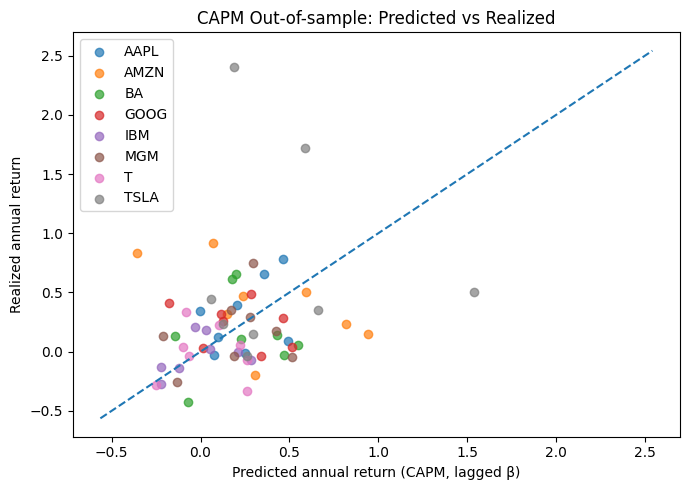

In [ ]:
def plot_capm_out_of_sample(pr, stocks,
                            x_col="r_pred_annual",
                            y_col="r_real_annual",
                            figsize=(7,5)):
    plt.figure(figsize=figsize)
    for s in stocks:
        sub = pr[pr["stock"] == s]
        if not sub.empty:
            plt.scatter(sub[x_col], sub[y_col], label=s, alpha=0.7)
    lims = plt.axis()
    lo, hi = min(lims[0], lims[2]), max(lims[1], lims[3])
    plt.plot([lo, hi], [lo, hi], linestyle="--")
    plt.xlabel("Predicted annual return (CAPM, lagged β)")
    plt.ylabel("Realized annual return")
    plt.title("CAPM Out-of-sample: Predicted vs Realized")
    plt.legend()
    plt.tight_layout()
    plt.show()

plot_capm_out_of_sample(pr_1y, stocks, x_col="r_pred_annual", y_col="r_real_annual")

This chart summarises and compares Expected Annual Returns (α≠0) with Realized Returns, showing a weak correlation (0.177). This highlights the model’s limited predictive power.

While many stocks **cluster around the central line** indicating no significant differences, Tesla showcases an interesting behaviour. It oscillates significantly (either violently overperforming or underperforming expectations), showing rather than a consistent and positive alpha, a **high level of volatility** which drives the deviations (in both directions) from CAPM predictions. This might be due to the fact the beta estimated based on data from the previous year might be quite different from the actual beta. To verify this, we plotted them below for each stock.

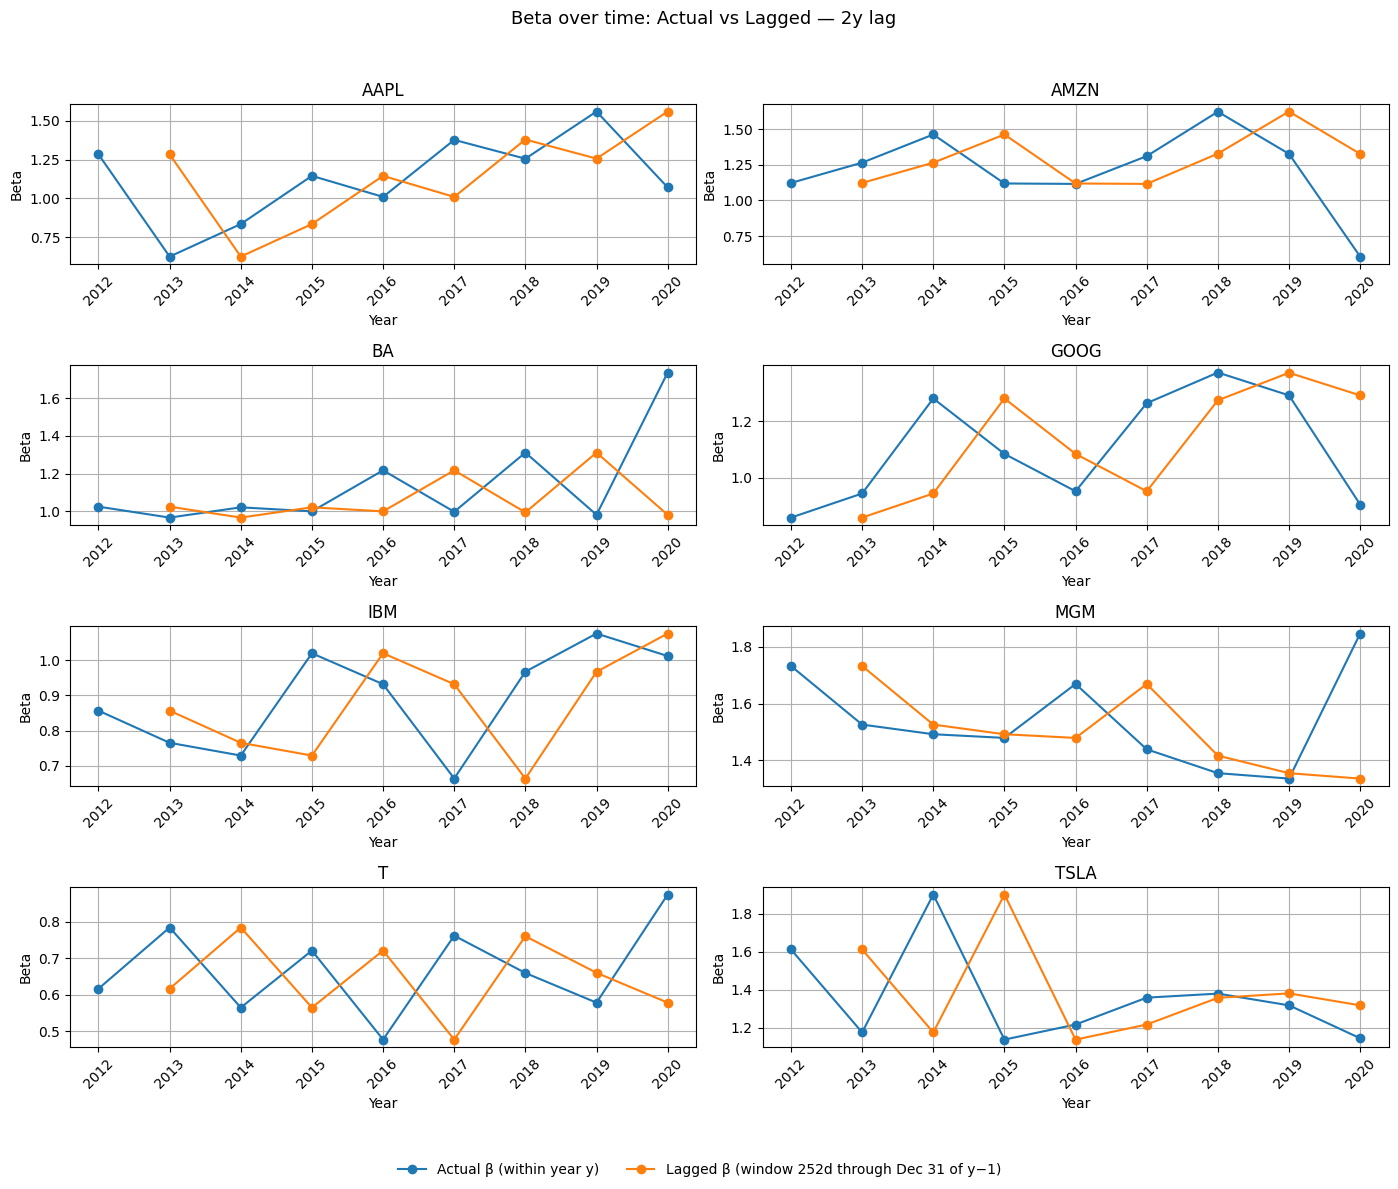

In [ ]:
def compute_beta_actual_by_year(returns,stocks, market_col,rf = 0.0):

    r = returns.copy()
    r.index = pd.to_datetime(r.index, errors="coerce")

    out = []
    for s in stocks:
        sub = r[[s, market_col]].dropna().copy()
        sub["year"] = sub.index.year

        for y, g in sub.groupby("year"):
            x = (g[market_col] - rf).to_numpy()
            yexc = (g[s] - rf).to_numpy()
            n = len(g)

            beta = np.cov(x, yexc, ddof=0)[0,1] / np.var(x, ddof=0)
            out.append({"stock": s, "year": int(y), "beta_actual": float(beta), "n_days": int(n)})

    return pd.DataFrame(out)


# plotting actual versus lagged beta time series
def plot_beta_lag_vs_actual_ts(pr_df,returns,stocks,market_col,rf = 0.0, title_suffix = ""):

    beta_act = compute_beta_actual_by_year(returns, stocks, market_col, rf=rf)

    win_lbl = ""
    if "window_days" in pr_df.columns and pd.notna(pr_df["window_days"]).any():
        try:
            w = int(pd.to_numeric(pr_df["window_days"], errors="coerce").dropna().iloc[0])
            win_lbl = f" (window {w}d through Dec 31 of y−1)"
        except Exception:
            pass

    nrows, ncols = 4, 2
    fig, axes = plt.subplots(nrows, ncols, figsize=(14, 12), sharex=False, sharey=False)
    axes = axes.ravel()

    all_years = set()
    for s in stocks:
        a = beta_act.loc[beta_act["stock"] == s, "year"]
        l = pr_df.loc[pr_df["stock"] == s, "year"]
        all_years.update(a.tolist())
        all_years.update(l.tolist())
    all_years = sorted(int(y) for y in all_years) if all_years else []

    for i, s in enumerate(stocks):
        ax = axes[i]
        a = beta_act.loc[beta_act["stock"] == s, ["year", "beta_actual"]]
        l = pr_df.loc[pr_df["stock"] == s, ["year", "beta_lag"]]

        m = pd.merge(a, l, on="year", how="outer").sort_values("year")
        years = m["year"].astype(int).to_numpy()

        ax.plot(years, m["beta_actual"].to_numpy(), marker="o", label="Actual β (within year y)")
        ax.plot(years, m["beta_lag"].to_numpy(), marker="o", label=f"Lagged β{win_lbl}")

        ax.set_title(f"{s}")
        ax.set_xlabel("Year")
        ax.set_ylabel("Beta")
        ax.grid(True)
        if all_years:
            ax.set_xticks(all_years)
        else:
            ax.set_xticks(years)
        for tick in ax.get_xticklabels():
            tick.set_rotation(45)


    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, loc="lower center", ncol=2, frameon=False)
    suptitle = "Beta over time: Actual vs Lagged"
    if title_suffix:
        suptitle += f" — {title_suffix}"
    fig.suptitle(suptitle, y=0.98, fontsize=13)
    plt.tight_layout(rect=(0, 0.05, 1, 0.96))
    plt.show()


plot_beta_lag_vs_actual_ts(pr_1y, returns, stocks, market_col, rf=0.0, title_suffix="2y lag")


Here above we plotted the movement over time of the **actual versus the lagged beta**. As one can see there are many fluctuations among these values. In highly volatile stocks such as Tesla we can see wide oscillation which cause the Return prediction for the next year to be quite distant from the true value as identified in the previous graph.

### Scatter plot of the realized returns against the beta

In [ ]:
def plot_year_for(pr: pd.DataFrame, y: int, title_prefix: str = None):
    sub = pr[pr["year"].astype(int) == int(y)].dropna(subset=["beta_lag","r_real_annual","r_pred_annual"])

    fig, ax = plt.subplots(figsize=(7,5))
    ax.scatter(sub["beta_lag"], sub["r_real_annual"], alpha=0.9)

    # OLS fit on realized returns vs beta
    m_real, b_real = np.polyfit(sub["beta_lag"], sub["r_real_annual"], 1)

    # CAPM-implied slope from predicted vs beta (≈ market return that year)
    m_capm = np.polyfit(sub["beta_lag"], sub["r_pred_annual"], 1)[0]

    xs = np.linspace(sub["beta_lag"].min()*0.95, sub["beta_lag"].max()*1.05, 200)
    ax.plot(xs, m_real*xs + b_real, linestyle="--", label=f"OLS(real): slope={m_real:.2f}")
    ax.plot(xs, m_capm*xs, linestyle=":",   label=f"SML (CAPM): slope≈{m_capm:.2f}")

    ax.set_xlabel("Lagged beta (β from y−1)")
    ax.set_ylabel("Realized annual return")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter(1.0))
    n = len(sub)
    ttl = f"Year {y}: Realized vs β  (n={n})"
    if title_prefix:
        ttl = f"{title_prefix} — {ttl}"
    ax.set_title(ttl)
    ax.legend()
    ax.grid(True)
    plt.show()

def interact_capm_plot(pr: pd.DataFrame, title_prefix: str = None):
    years = sorted(pd.unique(pd.to_numeric(pr["year"], errors="coerce").dropna().astype(int)))
    def _plot(y):
        plot_year_for(pr, y, title_prefix=title_prefix)
    interact(_plot, y=widgets.SelectionSlider(options=years, description="Year"))



interact_capm_plot(pr_1y, title_prefix="1y (252d)")


interactive(children=(SelectionSlider(description='Year', options=(np.int64(2013), np.int64(2014), np.int64(20…

From the graph above we can see that there is no clear relationship between the Realized Returns at time *t* and the Beta estimated at *t-1* used to estimate the Expected Returns at time *t*. From a financial point of view, this translates into the fact that **higher value of Beta (meaning higher risk) do not necessarily correspond to higher returns**.

In each figure of the graph above, the orange dotted line is the **Security Market Line (SML)** implied by the CAPM using betas estimated from the previous year and defined as follows:


$$
\mathbb{E}_t[R_{i,t}] = R_{f,t-1} + \beta_{i,t-1}\,\mathbb{E}_t[R_{M,t} - R_{f,t-1}].
$$

Assuming that the risk free rate is zero, its slope is roughly equal to that year’s realized market return.

The blue dashed line is the **OLS** fit of the Realized stock Returns on the lagged betas.

Using as example the year 2016 we can see that the **SML is steep** (strong market), but the OLS line is almost flat, meaning **high-beta stocks did not earn proportionally higher returns**. On the other hand, in 2017, the opposite occurs: the SML is gentle (moderate market), but the OLS line is steep, indicating a strong ex-post reward to beta. Economically, the contrast shows that the CAPM’s prediction is state-dependent: the market’s average return doesn’t always translate into beta premium in the year, because risk prices, betas, and other factor exposures vary over time.

This outcome might also be explained by the fact that betas were estimated over a relatively **short time window (252 days)**, making them more biased and less generalizable. For this reason, we decided to extend our training horizon, encompassing not anymore just one year, but two, to see whether the relationship between Beta and Realized Returns became more linear.


In [ ]:
pr_2y  = capm_oos_year_ahead(returns, stocks, market_col, window_days=504, rf=0.0)
pr_2y=pr_2y.loc[pr_2y["year"]!=2013]
pr_3y = capm_oos_year_ahead(returns, stocks, market_col, window_days=730, rf=0.0)
pr_3y=pr_3y.loc[(pr_3y["year"]!=2013)&(pr_3y["year"]!=2014)]


summarize(pr_2y,  "504-day (2y) estimation")
summarize(pr_3y,  "730-day (3y) estimation")

interact_capm_plot(pr_2y, title_prefix="2y (504d)")
interact_capm_plot(pr_3y, title_prefix="3y (730d)")


504-day (2y) estimation: corr=0.267, RMSE=0.416
730-day (3y) estimation: corr=0.263, RMSE=0.425


interactive(children=(SelectionSlider(description='Year', options=(np.int64(2014), np.int64(2015), np.int64(20…

interactive(children=(SelectionSlider(description='Year', options=(np.int64(2015), np.int64(2016), np.int64(20…

Also expanding the training horizon adopted (2 years and 3 years respectively) we did not observe any significant difference in hte dynamics between the lagged betas and the reallized returns. This might be a signal to **avoid relying solely on historical values** of beta as a risk measure, as some estimations may fail to capture the true underlying dynamics of each company.

# **Optional**: Empirical test of CAPM

### Cleaning and preparing the scraped dataset

We first reshape the scraped dataset into a wide format in order to match the other dataset used. Next, we merge in the S&P 500 index by date to obtain a complete dataset.
Finally we had to address missing data. Since some tickers contained many missing observations, often due to changes in the S&P 500 composition, we remove all columns with incomplete values, keeping only stocks with a complete price history.

In [ ]:
# Pivot the DataFrame so each Ticker is a column with its Close value
df_adj_close = df_web.pivot(index="Date", columns="Ticker", values="Adj Close")

df_adj_close = df_adj_close.reset_index()

df_adj_close.head()

Ticker,Date,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WY,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS
0,2012-01-12,25.166063,12.650179,NaN,20.267302,11.794311,41.967861,29.230000,27.359522,19.897564,...,11.973386,80.245934,16.936729,49.234818,21.410086,NaN,33.797634,47.693584,34.990002,NaN
1,2012-01-13,24.873135,12.602745,NaN,20.366501,11.781633,41.431019,28.969999,26.853537,19.918051,...,12.190430,78.820786,16.974808,49.316166,21.351772,NaN,34.003101,47.676262,34.970001,NaN
2,2012-01-17,25.465349,12.749543,NaN,20.469389,11.708730,41.617760,29.350000,27.161528,19.651747,...,12.220575,81.780693,16.943077,49.786800,21.351772,NaN,34.369606,47.806198,35.549999,NaN
3,2012-01-18,26.280441,12.881929,NaN,20.340786,11.715070,42.753696,29.889999,28.708797,19.952188,...,12.395410,85.369102,17.019220,50.228355,22.484753,NaN,34.797222,48.118019,36.540001,NaN
4,2012-01-19,26.649788,12.841109,NaN,20.366501,11.692883,42.636971,30.240000,29.090107,20.088762,...,12.666710,85.763725,16.873272,50.565331,22.176514,NaN,34.691727,48.629105,37.259998,NaN


In [ ]:
df["Date"] = pd.to_datetime(df["Date"])
df_adj_close["Date"] = pd.to_datetime(df_adj_close["Date"])

# Merge sp500
df_final_web = df_adj_close.merge(df[["Date", "sp500"]], on="Date", how="left")

df_final_web.head()

,Date,A,AAPL,ABBV,ABT,ACGL,ACN,ADBE,ADI,ADM,...,WYNN,XEL,XOM,XYL,XYZ,YUM,ZBH,ZBRA,ZTS,sp500
0,2012-01-12,25.166063,12.650179,NaN,20.267302,11.794311,41.967861,29.230000,27.359522,19.897564,...,80.245934,16.936729,49.234818,21.410086,NaN,33.797634,47.693584,34.990002,NaN,1295.500000
1,2012-01-13,24.873135,12.602745,NaN,20.366501,11.781633,41.431019,28.969999,26.853537,19.918051,...,78.820786,16.974808,49.316166,21.351772,NaN,34.003101,47.676262,34.970001,NaN,1289.089966
2,2012-01-17,25.465349,12.749543,NaN,20.469389,11.708730,41.617760,29.350000,27.161528,19.651747,...,81.780693,16.943077,49.786800,21.351772,NaN,34.369606,47.806198,35.549999,NaN,1293.670044
3,2012-01-18,26.280441,12.881929,NaN,20.340786,11.715070,42.753696,29.889999,28.708797,19.952188,...,85.369102,17.019220,50.228355,22.484753,NaN,34.797222,48.118019,36.540001,NaN,1308.040039
4,2012-01-19,26.649788,12.841109,NaN,20.366501,11.692883,42.636971,30.240000,29.090107,20.088762,...,85.763725,16.873272,50.565331,22.176514,NaN,34.691727,48.629105,37.259998,NaN,1314.500000


In [ ]:
missing_cols = df_final_web.columns[df_final_web.isna().any()]
print(missing_cols)

Index(['ABBV', 'ALLE', 'AMCR', 'ANET', 'CARR', 'CDW', 'CFG', 'CRWD', 'CTVA',
       'DAY', 'DDOG', 'DELL', 'DOW', 'EPAM', 'FANG', 'FOX', 'FOXA', 'FTV',
       'GDDY', 'HLT', 'HPE', 'HWM', 'INVH', 'IQV', 'IR', 'KEYS', 'KHC', 'LW',
       'META', 'MRNA', 'NCLH', 'NOW', 'NWS', 'NWSA', 'OTIS', 'PANW', 'PAYC',
       'PSX', 'PYPL', 'SYF', 'TTD', 'UBER', 'VICI', 'VST', 'WDAY', 'XYZ',
       'ZTS'],
      dtype='object')


In [ ]:
df_final_web = df_final_web.dropna(axis=1, how="any")

### Computing the returns and the betas

Using the same methods used above in Task 1 and Task 2, we compute the daily returns of the stocks in the new dataset and the OLS estimates for α and β.

In [ ]:
returns_web = df_final_web.set_index("Date").pct_change().dropna()
stocks_web = returns_web.columns.tolist()
returns_web.head()
market_col = "sp500"
stocks_web = [c for c in returns_web.columns if c != market_col]

In [ ]:
results_web, rows = {}, []
for s in stocks_web:
    pair = returns_web[[s, market_col]].dropna()
    y = pair[s]
    X = sm.add_constant(pair[market_col])
    res = sm.OLS(y, X).fit()
    results_web[s] = res
    rows.append({
        "stock": s,
        "alpha": res.params["const"],
        "beta": res.params[market_col],
        "alpha_t": res.tvalues["const"],
        "beta_t": res.tvalues[market_col],
        "alpha_pval": res.pvalues["const"],
        "beta_pval": res.pvalues[market_col],
        "R2": res.rsquared,
        "n_obs": int(res.nobs),
    })

summary_df_web = pd.DataFrame(rows).set_index("stock").sort_index()

sig_web = pd.DataFrame({
    "alpha_sig_5pct": summary_df_web["alpha_pval"] < 0.05,
    "beta_sig_5pct":  summary_df_web["beta_pval"]  < 0.05,
})


final_web = summary_df_web.join(sig_web)

final_web.head()

,alpha,beta,alpha_t,beta_t,alpha_pval,beta_pval,R2,n_obs,alpha_sig_5pct,beta_sig_5pct
stock,,,,,,,,,,
A,0.000198,1.091248,0.811193,46.898571,0.417344,0.000000e+00,0.505107,2157,False,True
AAPL,0.000606,1.111821,2.104347,40.521837,0.035464,2.273790e-267,0.432450,2157,True,True
ABT,0.000329,0.941337,1.538606,46.219491,0.124047,0.000000e+00,0.497814,2157,False,True
ACGL,0.000088,0.949874,0.373501,42.274967,0.708813,6.179719e-285,0.453347,2157,False,True
ACN,0.000329,1.063075,1.677970,56.875006,0.093498,0.000000e+00,0.600168,2157,False,True


### Empirical test of CAPM

To **test the CAPM empirically**, we use the estimated betas of all S&P 500 stocks to build their **empirical distribution**, and then sort the stocks into ten **deciles** based on the range of these beta values. For each decile portfolio, we compute the **average beta** and the corresponding **average annualized return**. We then plot these average returns against average betas and fit a simple linear regression line.

According to the CAPM, this relation should be **strongly positive and linear**, with higher-beta portfolios delivering proportionally higher returns.
Our results show a **weak positive relationship** between portfolio betas and average annualized returns. While the slope is positive, it is relatively flat and the dispersion of returns around the line is large.
This suggests that **beta alone does a poor job of explaining returns**, highlighting a key weakness of the CAPM.

In [ ]:
stocks_web = [c for c in returns_web.columns if c != market_col]

# compute average annualized returns for each stock
avg_annualized_returns = returns_web[stocks_web].mean() * 252

beta_returns_df = pd.DataFrame({
    "beta": final_web["beta"],
    "avg_annualized_return": avg_annualized_returns
})

beta_returns_df.head()

,beta,avg_annualized_return
A,1.091248,0.186706
AAPL,1.111821,0.292127
ABT,0.941337,0.200895
ACGL,0.949874,0.141249
ACN,1.063075,0.216224


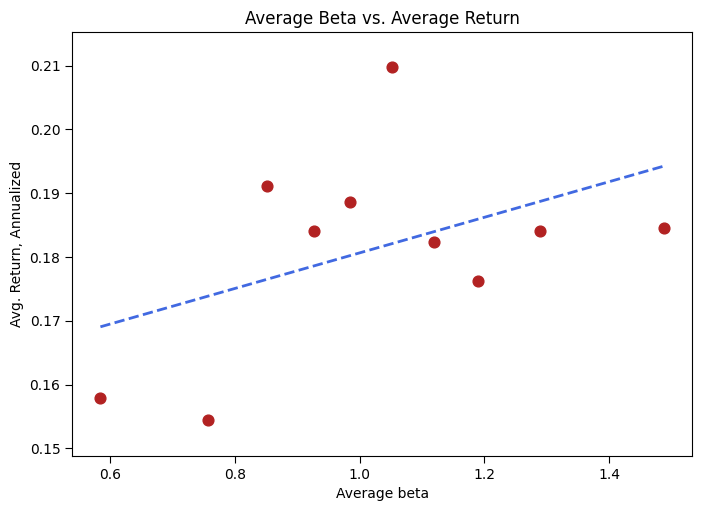

In [ ]:
# create beta deciles
beta_returns_df["beta_quantile"] = pd.qcut(beta_returns_df["beta"], 10, labels=False) + 1

# for each quantile, compute the average beta and the average return
deciles = (
    beta_returns_df
    .groupby("beta_quantile")
    .agg(mean_beta=("beta", "mean"),
         mean_return=("avg_annualized_return", "mean"))
    .sort_values("mean_beta")
)

x = deciles["mean_beta"].values
y = deciles["mean_return"].values

# fit linear regression line
a, b = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 200)
y_line = a * x_line + b

# plot
plt.figure(figsize=(8, 5.5))
plt.scatter(x, y, s=60, color="firebrick")
plt.plot(x_line, y_line, "--", color="royalblue", lw=2)

plt.xlabel("Average beta")
plt.ylabel("Avg. Return, Annualized")
plt.title("Average Beta vs. Average Return")

plt.margins(x=0.05, y=0.1)
plt.tick_params(axis="both", length=5)
plt.grid(False)

plt.show()